In [7]:
# Biblioteker
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from scipy.stats import chi2

In [ ]:
# Indlæs data
gdp = pd.read_csv("GDP.csv", skiprows=4)
aging = pd.read_csv("age-dependency-ratio-old.csv")
pwt = pd.read_excel("Human-Productivity.xlsx", sheet_name="Data")

ParserError: Error tokenizing data. C error: Expected 3 fields in line 5, saw 71


In [ ]:
# Tjek de har læst korrekt - Kan sletts, kun til kontrol
print(gdp.head())
print(gdp.columns[:10])

print(aging.head())
print(aging.columns)

print(pwt.head())
print(pwt.columns[:15])

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                  Indicator Name     Indicator Code  1960  \
0  GDP per capita, PPP (current international $)  NY.GDP.PCAP.PP.CD   NaN   
1  GDP per capita, PPP (current international $)  NY.GDP.PCAP.PP.CD   NaN   
2  GDP per capita, PPP (current international $)  NY.GDP.PCAP.PP.CD   NaN   
3  GDP per capita, PPP (current international $)  NY.GDP.PCAP.PP.CD   NaN   
4  GDP per capita, PPP (current international $)  NY.GDP.PCAP.PP.CD   NaN   

   1961  1962  1963  1964  1965  ...          2017          2018  \
0   NaN   NaN   NaN   NaN   NaN  ...  37524.914920  39287.059713   
1   NaN   NaN   NaN   NaN   NaN  ...   3837.726375   3723.216423   
2   NaN   NaN   NaN   NaN   NaN  ...   2335.795862

In [ ]:
# Clean GDP data
gdp = gdp.loc[:, ~gdp.columns.str.contains("^Unnamed")]

# Behold kun det nødvendige
gdp = gdp[["Country Name", "Country Code"] + [col for col in gdp.columns if col.isdigit()]]

# Lav fra wide til long format
gdp = gdp.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="GDP"
)

# Omdøb kolonner
gdp = gdp.rename(columns={"Country Name": "Country"})

# Ens datatype
gdp["Year"] = pd.to_numeric(gdp["Year"], errors="coerce")

# Tjek - kan slettes, kun til kontrol
print(gdp.head())
print(gdp.columns)
print(gdp.shape)

                       Country Country Code  Year  GDP
0                        Aruba          ABW  1960  NaN
1  Africa Eastern and Southern          AFE  1960  NaN
2                  Afghanistan          AFG  1960  NaN
3   Africa Western and Central          AFW  1960  NaN
4                       Angola          AGO  1960  NaN
Index(['Country', 'Country Code', 'Year', 'GDP'], dtype='object')
(17556, 4)


In [ ]:
# Clean aging
aging = aging.rename(columns={
    "Entity": "Country",
    "Code": "Country Code",
    "Age dependency ratio, old (% of working-age population)": "Age_dependency_old"
})

# Behold kun relevante kolonner
aging = aging[["Country", "Country Code", "Year", "Age_dependency_old"]]

# Ens datatype
aging["Year"] = pd.to_numeric(aging["Year"], errors="coerce")

# Tjek - kan slettes, kun til kontrol
print(aging.head())
print(aging.columns)
print(aging.shape)

       Country Country Code  Year  Age_dependency_old
0  Afghanistan          AFG  1950            5.078877
1  Afghanistan          AFG  1951            5.100585
2  Afghanistan          AFG  1952            5.114399
3  Afghanistan          AFG  1953            5.122446
4  Afghanistan          AFG  1954            5.126267
Index(['Country', 'Country Code', 'Year', 'Age_dependency_old'], dtype='object')
(19388, 4)


In [ ]:
# Clean PWT
pwt = pwt.rename(columns={
    "country": "Country",
    "countrycode": "Country Code",
    "year": "Year"
})

# Behold relevante kolonner inkl. teknologi
pwt = pwt[["Country", "Country Code", "Year", "hc", "ctfp"]]

# Ens datatype
pwt["Year"] = pd.to_numeric(pwt["Year"], errors="coerce")

# Tjek - kan slettes, kun til kontrol
print(pwt.head())
print(pwt.columns)
print(pwt.shape)

  Country Country Code  Year  hc  ctfp
0   Aruba          ABW  1950 NaN   NaN
1   Aruba          ABW  1951 NaN   NaN
2   Aruba          ABW  1952 NaN   NaN
3   Aruba          ABW  1953 NaN   NaN
4   Aruba          ABW  1954 NaN   NaN
Index(['Country', 'Country Code', 'Year', 'hc', 'ctfp'], dtype='object')
(13690, 5)


In [ ]:
# Merge data
df = aging.merge(gdp, on=["Country Code", "Year"], how="inner")
df = df.merge(pwt, on=["Country Code", "Year"], how="inner")

# kan slettes, kun til kontrol
print(df.shape)
print(df.head())
print(df.isna().sum())

(11648, 9)
  Country_x Country Code  Year  Age_dependency_old Country_y  GDP  Country  \
0   Albania          ALB  1960           10.268960   Albania  NaN  Albania   
1   Albania          ALB  1961           10.132406   Albania  NaN  Albania   
2   Albania          ALB  1962            9.930125   Albania  NaN  Albania   
3   Albania          ALB  1963            9.761269   Albania  NaN  Albania   
4   Albania          ALB  1964            9.618436   Albania  NaN  Albania   

   hc  ctfp  
0 NaN   NaN  
1 NaN   NaN  
2 NaN   NaN  
3 NaN   NaN  
4 NaN   NaN  
Country_x                0
Country Code             0
Year                     0
Age_dependency_old       0
Country_y                0
GDP                   5673
Country                  0
hc                    3138
ctfp                  5044
dtype: int64


In [ ]:
# Drop rækker med manglende værdier i de relevante kolonner
df_clean = df.dropna(subset=["GDP", "hc", "Age_dependency_old", "ctfp"]).copy()

# kan slettes, kun til kontrol
print(df_clean.shape)
print(df_clean.isna().sum())
print(df_clean.head())

(3972, 9)
Country_x             0
Country Code          0
Year                  0
Age_dependency_old    0
Country_y             0
GDP                   0
Country               0
hc                    0
ctfp                  0
dtype: int64
   Country_x Country Code  Year  Age_dependency_old Country_y          GDP  \
30   Albania          ALB  1990            8.680737   Albania  2655.673133   
31   Albania          ALB  1991            8.855720   Albania  1988.640611   
32   Albania          ALB  1992            9.075256   Albania  1899.258869   
33   Albania          ALB  1993            9.350662   Albania  2143.176074   
34   Albania          ALB  1994            9.652499   Albania  2385.279580   

    Country        hc      ctfp  
30  Albania  2.516159  0.305903  
31  Albania  2.515733  0.297097  
32  Albania  2.515308  0.296830  
33  Albania  2.514883  0.328587  
34  Albania  2.514457  0.326567  


##  Deskriptiv statistik 

In [ ]:
# Deskriptive statistikker
print(df_clean.describe())

              Year  Age_dependency_old            GDP           hc  \
count  3972.000000         3972.000000    3972.000000  3972.000000   
mean   2006.700655           13.434893   19450.250035     2.555672   
std       9.700489            8.760495   21692.370836     0.685763   
min    1990.000000            1.012210     291.989333     1.029605   
25%    1998.000000            6.136805    4530.541522     2.040766   
50%    2007.000000            9.479952   11685.786536     2.645313   
75%    2015.000000           20.461015   27473.934267     3.111972   
max    2023.000000           50.120530  180939.439450     3.986023   

              ctfp  
count  3972.000000  
mean      0.667762  
std       0.275155  
min       0.065554  
25%       0.458613  
50%       0.652132  
75%       0.850455  
max       2.929296  


In [ ]:
# Sortér data
df_clean = df_clean.sort_values(["Country Code", "Year"])

# Beregn årlig vækst i GDP
df_clean["gdp_growth"] = df_clean.groupby("Country Code")["GDP"].pct_change()

# Identificer recessioner
df_clean["recession"] = (df_clean["gdp_growth"] < 0).astype(int)

# Drop rækker med manglende værdier i gdp_growth
df_clean = df_clean.dropna(subset=["gdp_growth"])

In [ ]:
# kan slettes, kun til kontrol
df_clean[["Country", "Year", "GDP", "gdp_growth", "recession", "ctfp"]].head(10)

,Country,Year,GDP,gdp_growth,recession,ctfp
159,Angola,1991,3740.350835,0.009579,0,0.284420
160,Angola,1992,3486.206867,-0.067947,1,0.325480
161,Angola,1993,2627.588101,-0.246290,1,0.249031
162,Angola,1994,2632.888199,0.002017,0,0.238681
163,Angola,1995,2989.761380,0.135544,0,0.186592
164,Angola,1996,3341.911888,0.117785,0,0.201034
165,Angola,1997,3525.083430,0.054810,0,0.189832
166,Angola,1998,3609.092978,0.023832,0,0.180385
167,Angola,1999,3618.776082,0.002683,0,0.164660
168,Angola,2000,3689.537808,0.019554,0,0.139858


In [ ]:
print(pwt.columns)

Index(['Country', 'Country Code', 'Year', 'hc', 'ctfp'], dtype='object')


### OLS regression (Ordinary Least Squares)

In [ ]:
df_clean["log_gdp"] = np.log(df_clean["GDP"])

X = df_clean[["ctfp", "Age_dependency_old", "hc", "recession"]]
X = sm.add_constant(X)

y = df_clean["log_gdp"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_gdp   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     2398.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:35:54   Log-Likelihood:                -3786.0
No. Observations:                3853   AIC:                             7582.
Df Residuals:                    3848   BIC:                             7613.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.4594      0

### FE

In [ ]:
df_clean["log_gdp"] = np.log(df_clean["GDP"])
df_panel = df_clean.set_index(["Country Code", "Year"])

fe = PanelOLS.from_formula(
    "log_gdp ~ ctfp + Age_dependency_old + hc + recession + EntityEffects + TimeEffects",
    data=df_panel
).fit()

print(fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_gdp   R-squared:                        0.1977
Estimator:                   PanelOLS   R-squared (Between):              0.1040
No. Observations:                3853   R-squared (Within):               0.0967
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.1041
Time:                        14:35:54   Log-likelihood                    1625.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      227.74
Entities:                         119   P-value                           0.0000
Avg Obs:                       32.378   Distribution:                  F(4,3698)
Min Obs:                       21.000                                           
Max Obs:                       33.000   F-statistic (robust):             227.74
                            

### RE

In [ ]:
from linearmodels.panel import RandomEffects

# (df_panel har du allerede lavet)
# df_panel = df_clean.set_index(["Country Code", "Year"])

re = RandomEffects.from_formula(
    "log_gdp ~ ctfp + Age_dependency_old + hc + recession",
    data=df_panel
).fit()

print(re.summary)


                        RandomEffects Estimation Summary                        
Dep. Variable:                log_gdp   R-squared:                        0.7570
Estimator:              RandomEffects   R-squared (Between):              0.8425
No. Observations:                3853   R-squared (Within):               0.7054
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.8410
Time:                        14:35:54   Log-likelihood                   -527.39
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2997.6
Entities:                         119   P-value                           0.0000
Avg Obs:                       32.378   Distribution:                  F(4,3849)
Min Obs:                       21.000                                           
Max Obs:                       33.000   F-statistic (robust):             2997.6
                            

### Hausman test

In [ ]:
import numpy as np
from scipy.stats import chi2

# Hent koefficienter (kun fælles variable)
fe_params = fe.params[["ctfp", "Age_dependency_old", "hc", "recession"]]
re_params = re.params[["ctfp", "Age_dependency_old", "hc", "recession"]]

fe_cov = fe.cov.loc[fe_params.index, fe_params.index]
re_cov = re.cov.loc[re_params.index, re_params.index]

diff = fe_params - re_params

stat = np.dot(np.dot(diff.T, np.linalg.inv(fe_cov - re_cov)), diff)

df = len(diff)
p_value = 1 - chi2.cdf(stat, df)

print("Hausman test statistic:", stat)
print("p-value:", p_value)

Hausman test statistic: 7489.00847061802
p-value: 0.0


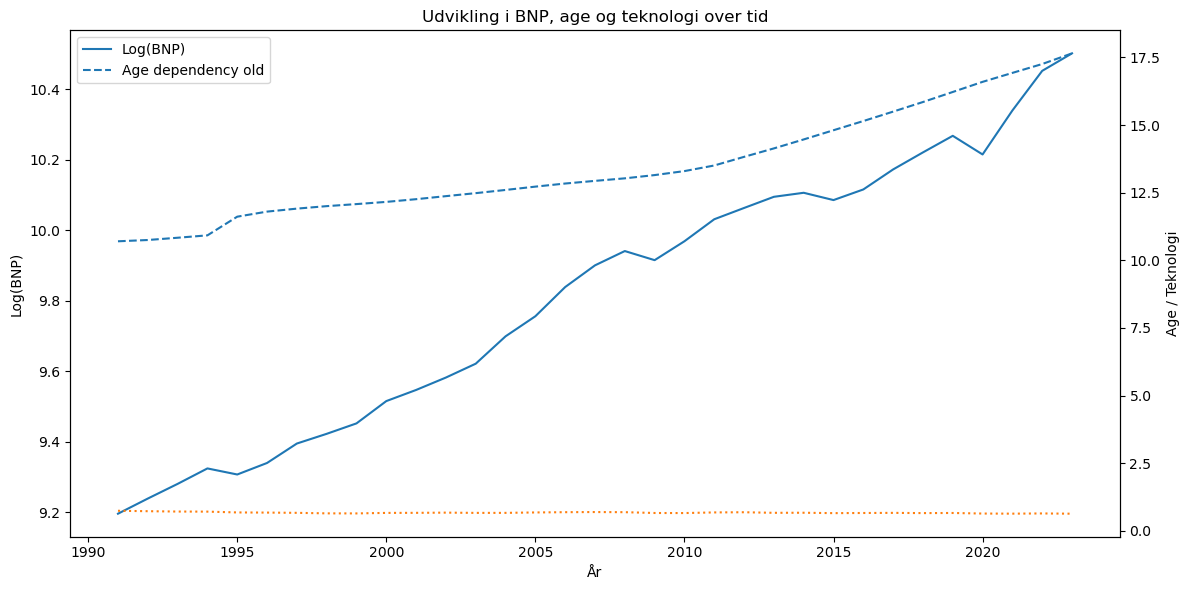

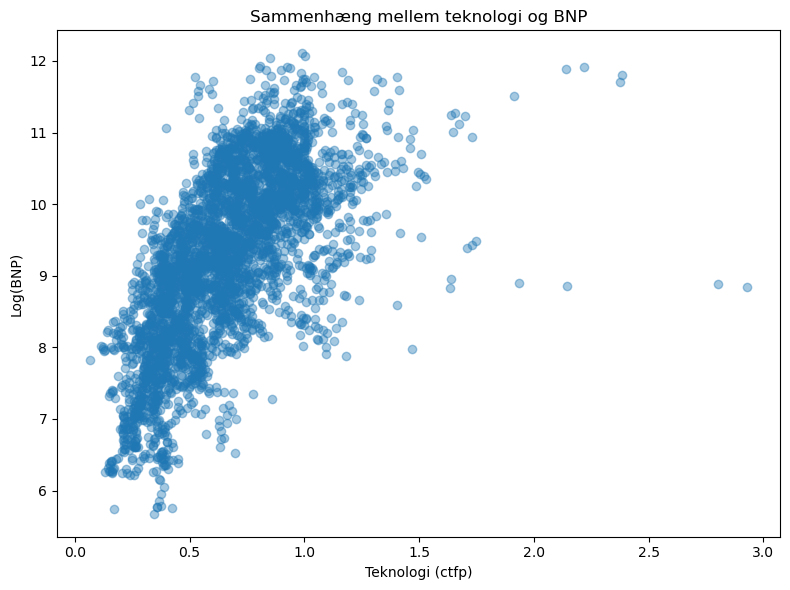

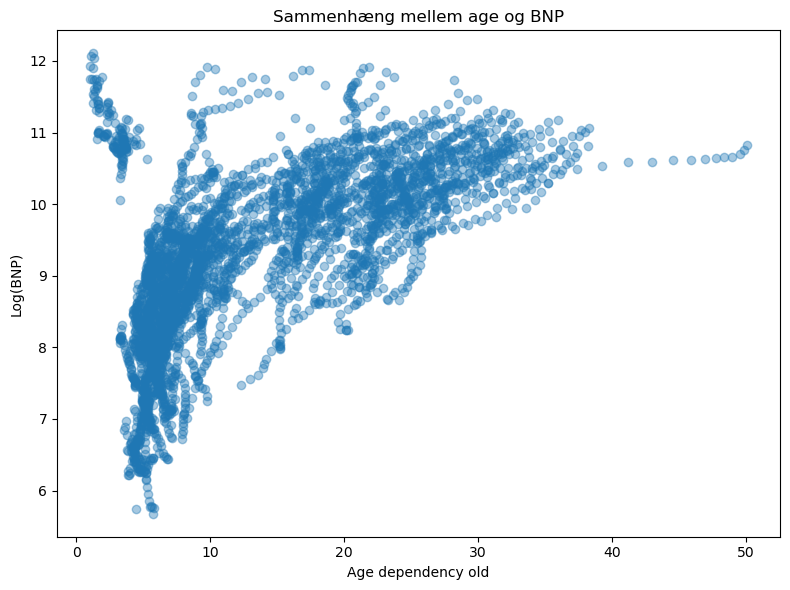

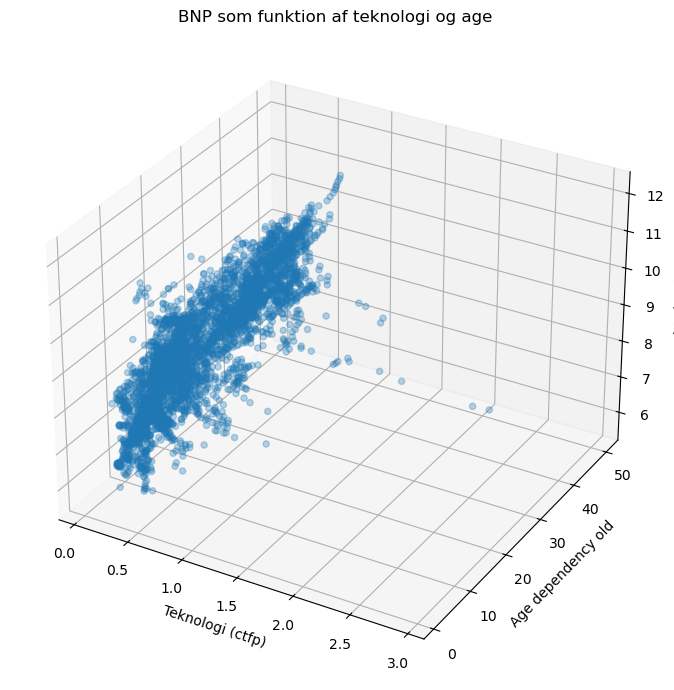

In [ ]:
import matplotlib.pyplot as plt

# Vælg verdensgennemsnit pr. år, så udviklingen bliver mere overskuelig
plot_df = (
    df_clean.groupby("Year")[["GDP", "Age_dependency_old", "ctfp"]]
    .mean()
    .reset_index()
)

# Log af BNP så skalaen bliver pænere
plot_df["log_GDP"] = np.log(plot_df["GDP"])

# -------- 1. Udvikling over tid --------
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(plot_df["Year"], plot_df["log_GDP"], label="Log(BNP)")
ax1.set_xlabel("År")
ax1.set_ylabel("Log(BNP)")

ax2 = ax1.twinx()
ax2.plot(plot_df["Year"], plot_df["Age_dependency_old"], linestyle="--", label="Age dependency old")
ax2.plot(plot_df["Year"], plot_df["ctfp"], linestyle=":")
ax2.set_ylabel("Age / Teknologi")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Udvikling i BNP, age og teknologi over tid")
plt.tight_layout()
plt.show()


# -------- 2. Teknologi mod BNP --------
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["ctfp"], df_clean["log_gdp"], alpha=0.4)
plt.xlabel("Teknologi (ctfp)")
plt.ylabel("Log(BNP)")
plt.title("Sammenhæng mellem teknologi og BNP")
plt.tight_layout()
plt.show()


# -------- 3. Age mod BNP --------
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["Age_dependency_old"], df_clean["log_gdp"], alpha=0.4)
plt.xlabel("Age dependency old")
plt.ylabel("Log(BNP)")
plt.title("Sammenhæng mellem age og BNP")
plt.tight_layout()
plt.show()


# -------- 4. 3D-figur med alle tre --------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_clean["ctfp"],
    df_clean["Age_dependency_old"],
    df_clean["log_gdp"],
    alpha=0.3
)

ax.set_xlabel("Teknologi (ctfp)")
ax.set_ylabel("Age dependency old")
ax.set_zlabel("Log(BNP)")
ax.set_title("BNP som funktion af teknologi og age")

plt.tight_layout()
plt.show()

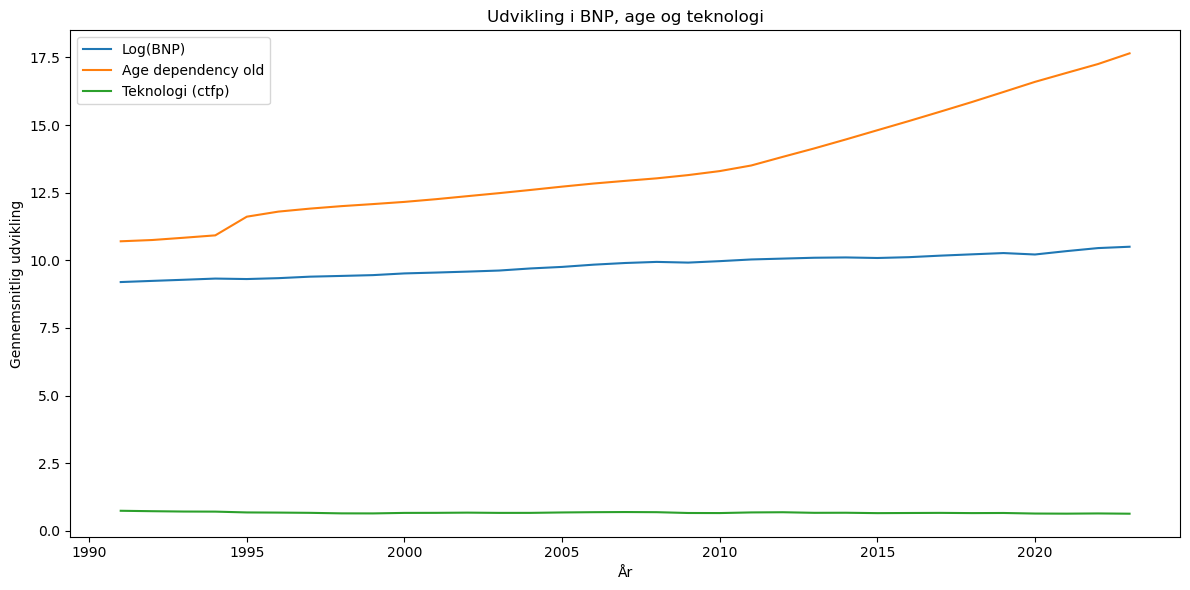

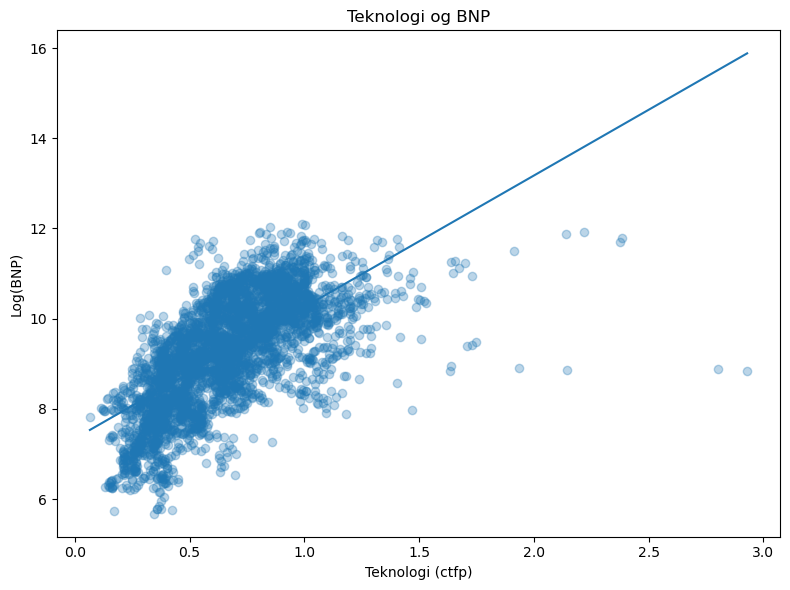

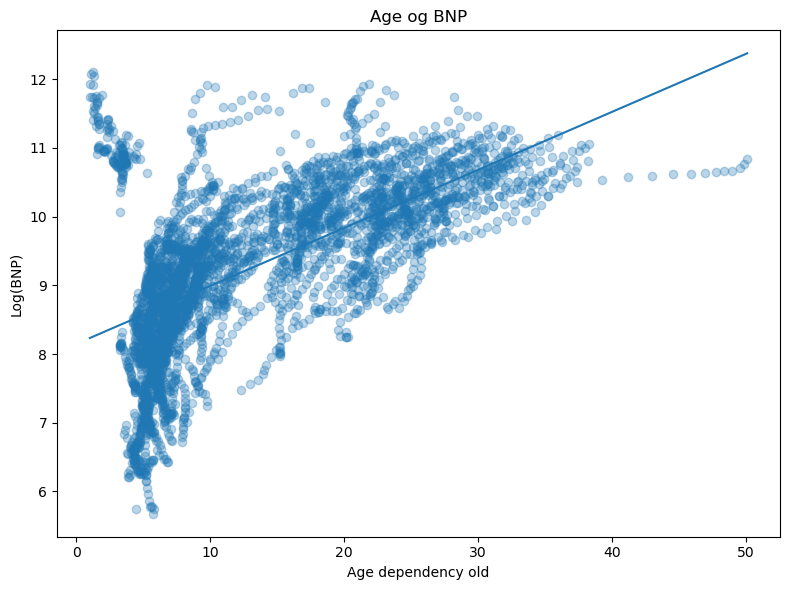

In [ ]:
import matplotlib.pyplot as plt

# 1. Gennemsnit over tid
plot_df = (
    df_clean.groupby("Year")[["GDP", "Age_dependency_old", "ctfp"]]
    .mean()
    .reset_index()
)

plot_df["log_GDP"] = np.log(plot_df["GDP"])

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Year"], plot_df["log_GDP"], label="Log(BNP)")
plt.plot(plot_df["Year"], plot_df["Age_dependency_old"], label="Age dependency old")
plt.plot(plot_df["Year"], plot_df["ctfp"], label="Teknologi (ctfp)")
plt.xlabel("År")
plt.ylabel("Gennemsnitlig udvikling")
plt.title("Udvikling i BNP, age og teknologi")
plt.legend()
plt.tight_layout()
plt.show()


# 2. Teknologi og BNP med trendlinje
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["ctfp"], df_clean["log_gdp"], alpha=0.3)

z1 = np.polyfit(df_clean["ctfp"], df_clean["log_gdp"], 1)
p1 = np.poly1d(z1)
x1 = np.linspace(df_clean["ctfp"].min(), df_clean["ctfp"].max(), 100)
plt.plot(x1, p1(x1))

plt.xlabel("Teknologi (ctfp)")
plt.ylabel("Log(BNP)")
plt.title("Teknologi og BNP")
plt.tight_layout()
plt.show()


# 3. Age og BNP med trendlinje
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["Age_dependency_old"], df_clean["log_gdp"], alpha=0.3)

z2 = np.polyfit(df_clean["Age_dependency_old"], df_clean["log_gdp"], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df_clean["Age_dependency_old"].min(), df_clean["Age_dependency_old"].max(), 100)
plt.plot(x2, p2(x2))

plt.xlabel("Age dependency old")
plt.ylabel("Log(BNP)")
plt.title("Age og BNP")
plt.tight_layout()
plt.show()